In [12]:
# Importing the Libraries and loading the dataset. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

df = pd.read_csv("FINAL_Dataset.csv")

# Focus on key columns
cols = ["Sleep Duration_mean","Stress Level_mean","Heart Rate_mean"]
print(df[cols].describe())


       Sleep Duration_mean  Stress Level_mean  Heart Rate_mean
count            43.000000          43.000000        43.000000
mean              7.186279           5.372093        70.798372
std               0.633076           1.351547         3.709842
min               5.800000           3.000000        65.000000
25%               6.950000           4.550000        69.065000
50%               7.220000           5.500000        70.240000
75%               7.435000           5.950000        71.205000
max               8.420000           8.000000        81.000000


1. Goal - Test whether average sleep duration is related to average stress level.
- Variables:
* X = Sleep Duration_mean (hours of sleep per night).
* Y = Stress Level_mean (average perceived stress score).
  
2. Hypotheses
- Null hypothesis (H0):
There is no linear relationship between sleep duration and stress level in the population
- Alternative hypothesis (H1):
There is a linear relationship between sleep duration and stress level in the population

In [13]:
# Keep only rows where all 3 variables are present

data = df[cols].dropna()
print("Rows after dropping NA:", len(data))


Rows after dropping NA: 43


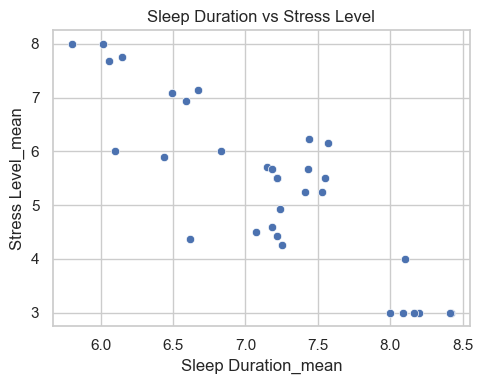

In [14]:
# Checking for Linearity and outliers

plt.figure(figsize=(5,4))
sns.scatterplot(data=data,
                x="Sleep Duration_mean",
                y="Stress Level_mean")
plt.title("Sleep Duration vs Stress Level")
plt.xlabel("Sleep Duration_mean")
plt.ylabel("Stress Level_mean")
plt.tight_layout()
plt.show()


Linearity and Outliers:

Checked using the scatter plot of Sleep Duration_mean vs Stress Level_mean.
- The points form a clear, roughly straight downward pattern:
more sleep → lower stress (strong negative trend).
- There are no isolated extreme points far away from the main cloud,
so there are no obvious influential outliers in the relationship.
- Conclusion: Linearity and absence of major outliers assumptions are satisfied.

Shapiro Sleep:  W=0.930 p=0.0120
Shapiro Stress: W=0.923 p=0.0065


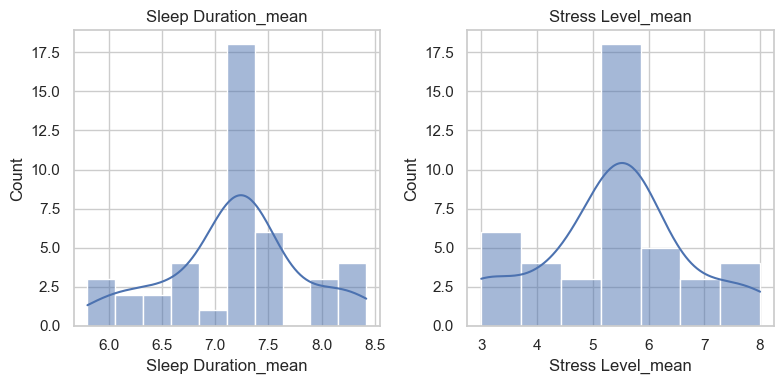

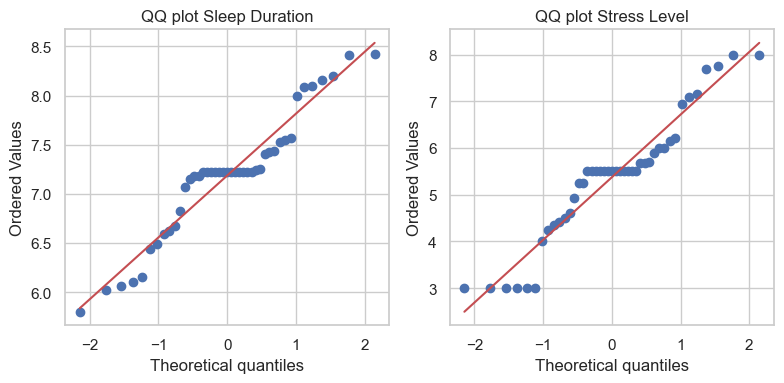

In [15]:
sleep = data["Sleep Duration_mean"]
stress = data["Stress Level_mean"]

# Shapiro–Wilk normality test
sh_sleep = stats.shapiro(sleep)
sh_stress = stats.shapiro(stress)
print("Shapiro Sleep:  W=%.3f p=%.4f" % (sh_sleep.statistic, sh_sleep.pvalue))
print("Shapiro Stress: W=%.3f p=%.4f" % (sh_stress.statistic, sh_stress.pvalue))

# Histograms
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(sleep, kde=True, ax=axes[0])
axes[0].set_title("Sleep Duration_mean")
sns.histplot(stress, kde=True, ax=axes[1])
axes[1].set_title("Stress Level_mean")
plt.tight_layout()
plt.show()

# QQ plots
fig, axes = plt.subplots(1,2, figsize=(8,4))
stats.probplot(sleep, dist="norm", plot=axes[0])
axes[0].set_title("QQ plot Sleep Duration")
stats.probplot(stress, dist="norm", plot=axes[1])
axes[1].set_title("QQ plot Stress Level")
plt.tight_layout()
plt.show()


Normality of each variable

Checked using histograms with KDE curves and QQ plots for Sleep Duration_mean and Stress Level_mean.
  
- Histograms appear approximately bell‑shaped with only slight skew for both variables.
- QQ plots show most points lying close to the reference line, with mild curvature
in the middle and at the tails, indicating near‑normal but not perfect distributions.

  Shapiro–Wilk tests:
  
* Sleep Duration_mean: W = 0.930, p = 0.012.
* Stress Level_mean: W = 0.923, p = 0.0065.
- The p‑values < 0.05 formally indicate deviations from perfect normality,
but visual checks suggest only modest departures and the sample size is small.
- Pearson’s correlation is generally robust to such mild non‑normality.

Test used
- Statistical test: Pearson correlation coefficient between Sleep Duration_mean and Stress Level_mean.
  
This test is appropriate because:
* Both variables are continuous.
* Relationship is approximately linear.
* No serious outliers.

In [16]:
r_sleep_stress, p_sleep_stress = stats.pearsonr(sleep, stress)
print("Sleep vs Stress: r = %.3f, p = %.4f" % (r_sleep_stress, p_sleep_stress))

alpha = 0.05
if p_sleep_stress < alpha:
    print("Conclusion: Significant negative relationship – more sleep ≈ lower stress.")
else:
    print("Conclusion: No significant relationship.")


Sleep vs Stress: r = -0.858, p = 0.0000
Conclusion: Significant negative relationship – more sleep ≈ lower stress.


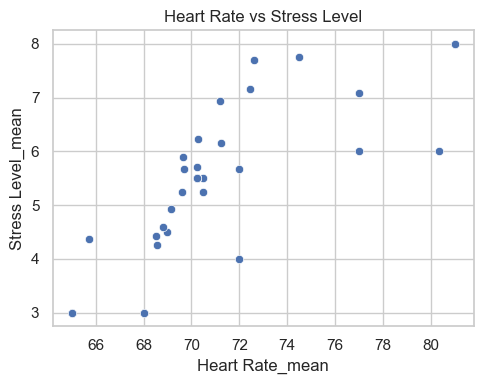

In [20]:
# Heart rate linearity check 

plt.figure(figsize=(5,4))
sns.scatterplot(data=data,
                x="Heart Rate_mean",
                y="Stress Level_mean")
plt.title("Heart Rate vs Stress Level")
plt.xlabel("Heart Rate_mean")
plt.ylabel("Stress Level_mean")
plt.tight_layout()
plt.show()


No linearity was found in this hence, we could not perfrom the Pearsons Test.
A Spearman's test needs to be perfromed. 